# Exploratory Data Analysis (EDA) — IPL Matches
**Internship Project 3 — Thiranex | Data Science**

**Goal:** Analyze IPL matches data to uncover patterns, trends, and key insights.

**Steps:**
- Statistical summaries
- Correlation analysis
- Pattern & trend discovery
- Structured insights

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 12

print('Libraries loaded!')

Libraries loaded!


## 2. Load Dataset

In [2]:
df = pd.read_csv('../data/matches_cleaned.csv')
print('Shape:', df.shape)
df.head()

Shape: (1095, 20)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2,toss_match_win
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen,False
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,MR Benson,SL Shastri,True
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,Aleem Dar,GA Pratapkumar,False
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,SJ Davis,DJ Harper,False
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,BF Bowden,K Hariharan,False


## 3. Statistical Summary

In [3]:
print('=== Numerical Summary ===')
df.describe()

=== Numerical Summary ===


,id,season,result_margin,target_runs,target_overs
count,1.095000e+03,1095.000000,1095.000000,1095.000000,1095.000000
mean,9.048283e+05,2016.180822,16.959817,165.230137,19.705205
std,3.677402e+05,4.994897,21.714792,34.487313,1.887000
min,3.359820e+05,2008.000000,0.000000,0.000000,0.000000
25%,5.483315e+05,2012.000000,5.000000,146.000000,20.000000
50%,9.809610e+05,2016.000000,8.000000,166.000000,20.000000
75%,1.254062e+06,2021.000000,19.000000,187.000000,20.000000
max,1.426312e+06,2024.000000,146.000000,288.000000,20.000000


In [4]:
print('=== Categorical Summary ===')
cat_cols = ['toss_decision', 'result', 'winner', 'city']
for col in cat_cols:
    print(f'\n{col} — unique values: {df[col].nunique()}')
    print(df[col].value_counts().head(5))

=== Categorical Summary ===

toss_decision — unique values: 2
toss_decision
field    704
bat      391
Name: count, dtype: int64

result — unique values: 4
result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64

winner — unique values: 20
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Name: count, dtype: int64

city — unique values: 38
city
Mumbai       173
Kolkata       93
Delhi         90
Chennai       85
Hyderabad     77
Name: count, dtype: int64


## 4. EDA — Patterns & Trends
### Chart 1 — IPL Matches Trend Over Seasons

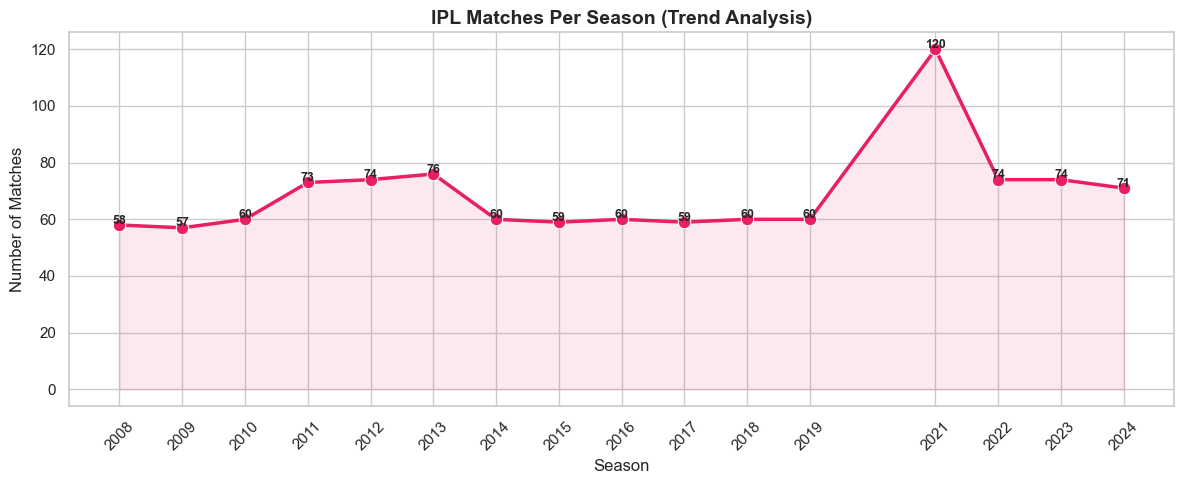

Insight: IPL has grown consistently — expansion of teams caused jumps in match count.


In [5]:
season_matches = df.groupby('season').size().reset_index(name='matches')

plt.figure(figsize=(12, 5))
sns.lineplot(data=season_matches, x='season', y='matches',
             marker='o', color='#E91E63', linewidth=2.5, markersize=9)
plt.fill_between(season_matches['season'], season_matches['matches'], alpha=0.1, color='#E91E63')
for _, row in season_matches.iterrows():
    plt.text(row['season'], row['matches'] + 0.5, str(int(row['matches'])),
             ha='center', fontsize=9, fontweight='bold')
plt.title('IPL Matches Per Season (Trend Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(season_matches['season'], rotation=45)
plt.tight_layout()
plt.savefig('../output/eda_season_trend.png', dpi=150)
plt.show()
print('Insight: IPL has grown consistently — expansion of teams caused jumps in match count.')

### Chart 2 — Team Win Rate (Wins vs Matches Played)

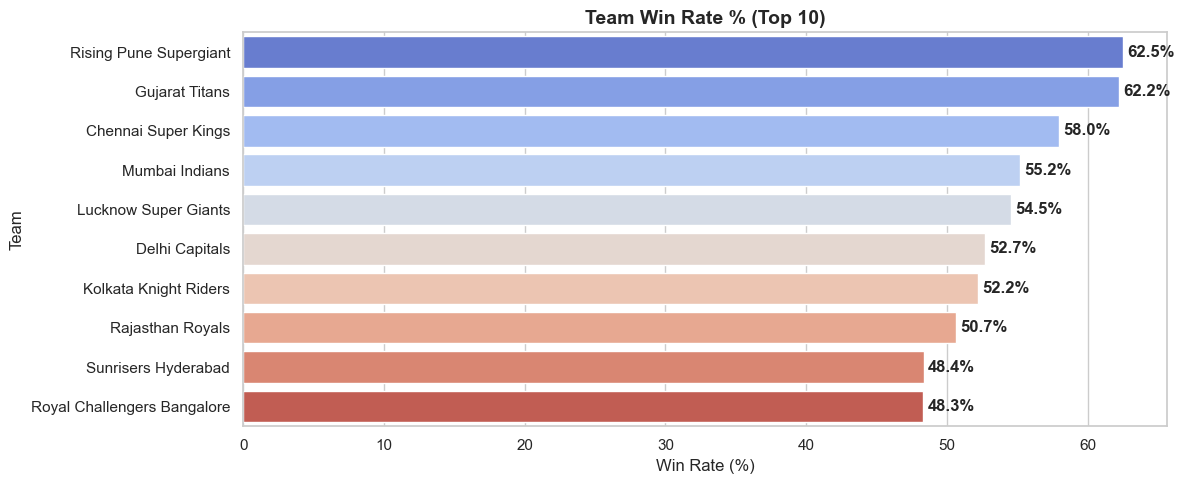

Insight: Win rate is a better metric than total wins — it accounts for how many matches a team played.


In [6]:
# Count total matches played per team
team1 = df['team1'].value_counts()
team2 = df['team2'].value_counts()
total_matches = (team1.add(team2, fill_value=0)).astype(int)

# Count wins
wins = df[df['winner'] != 'No Result']['winner'].value_counts()

# Win rate
win_rate = (wins / total_matches * 100).dropna().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=win_rate.values, y=win_rate.index, palette='coolwarm')
plt.title('Team Win Rate % (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Win Rate (%)')
plt.ylabel('Team')
for i, v in enumerate(win_rate.values):
    plt.text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../output/eda_win_rate.png', dpi=150)
plt.show()
print('Insight: Win rate is a better metric than total wins — it accounts for how many matches a team played.')

### Chart 3 — Toss Decision Trend Per Season

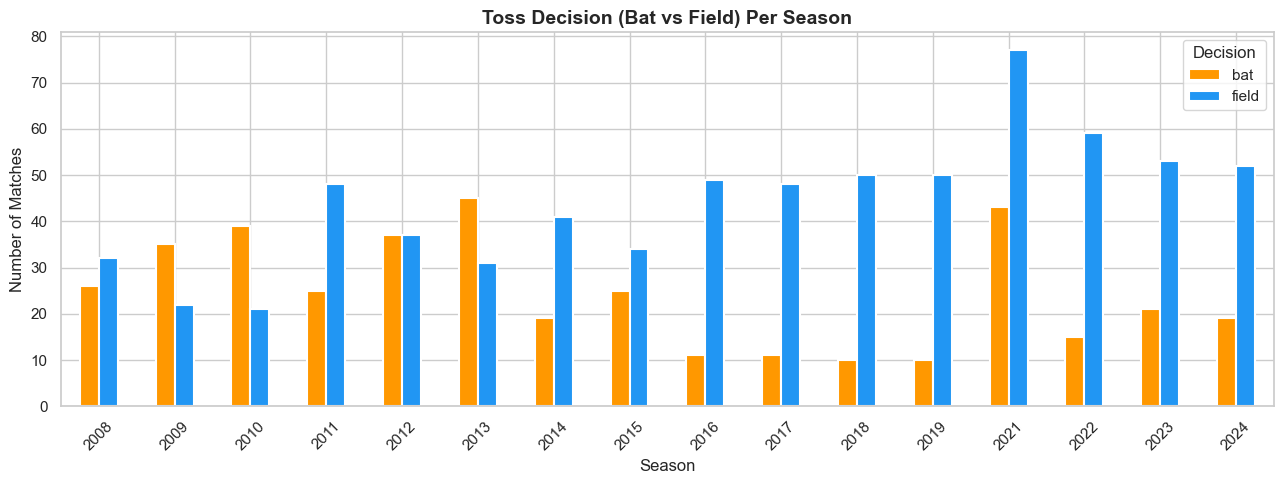

Insight: Teams increasingly prefer to field first (chase) in modern IPL seasons.


In [7]:
toss_trend = df.groupby(['season', 'toss_decision']).size().unstack(fill_value=0)

toss_trend.plot(kind='bar', figsize=(13, 5), color=['#FF9800', '#2196F3'],
                edgecolor='white', linewidth=1.5)
plt.title('Toss Decision (Bat vs Field) Per Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.legend(title='Decision')
plt.tight_layout()
plt.savefig('../output/eda_toss_trend.png', dpi=150)
plt.show()
print('Insight: Teams increasingly prefer to field first (chase) in modern IPL seasons.')

### Chart 4 — Correlation Heatmap

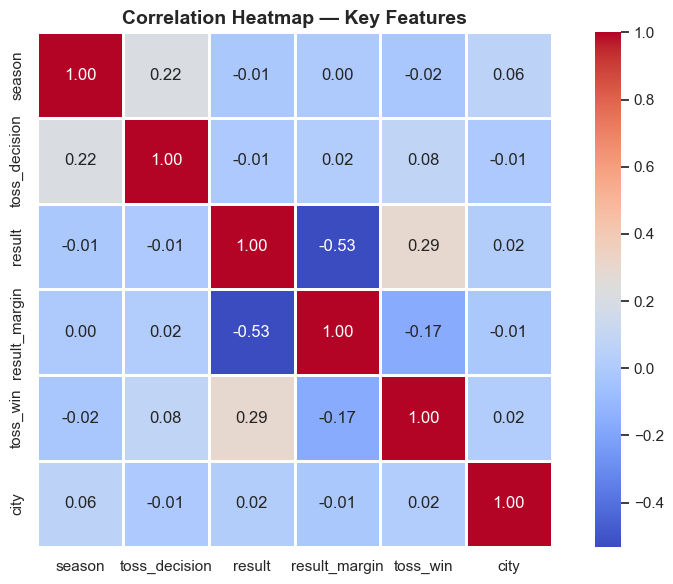

Insight: toss_win and toss_decision show weak correlation with result — toss is not a strong predictor.


In [8]:
# Encode columns for correlation
df_corr = df.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['toss_decision', 'result', 'city']:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))
df_corr['toss_win'] = (df_corr['toss_winner'] == df_corr['winner']).astype(int)

corr_cols = ['season', 'toss_decision', 'result', 'result_margin', 'toss_win', 'city']
corr = df_corr[corr_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=1, linecolor='white', square=True)
plt.title('Correlation Heatmap — Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/eda_correlation_heatmap.png', dpi=150)
plt.show()
print('Insight: toss_win and toss_decision show weak correlation with result — toss is not a strong predictor.')

### Chart 5 — Result Margin Distribution by Win Type

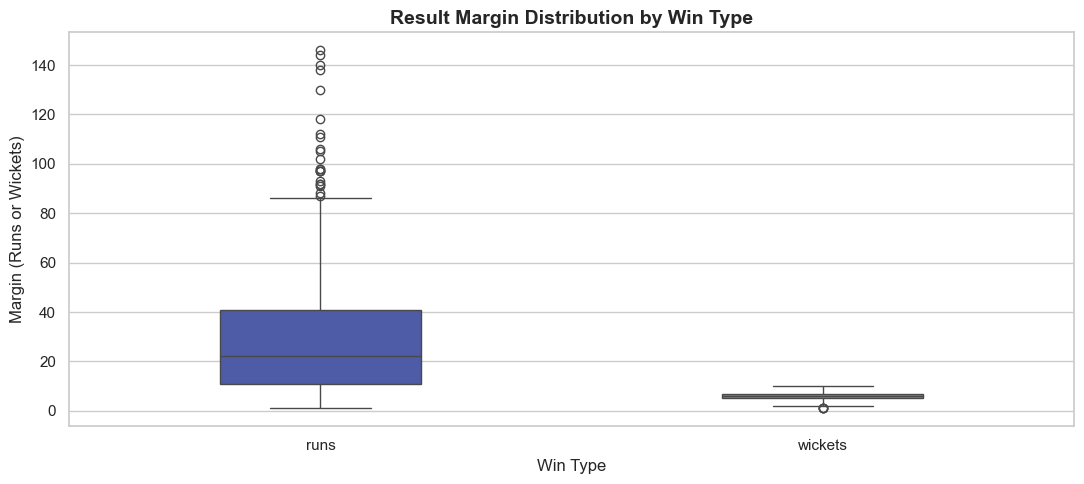

Insight: Wins by runs have higher variance — some blowout wins by 100+ runs.
Wins by wickets are more consistent — usually 1-6 wickets margin.


In [9]:
df_result = df[(df['result_margin'] > 0) & (df['winner'] != 'No Result')]

plt.figure(figsize=(11, 5))
sns.boxplot(data=df_result, x='result', y='result_margin',
            palette=['#3F51B5', '#FF5722'], width=0.4)
plt.title('Result Margin Distribution by Win Type', fontsize=14, fontweight='bold')
plt.xlabel('Win Type')
plt.ylabel('Margin (Runs or Wickets)')
plt.tight_layout()
plt.savefig('../output/eda_margin_distribution.png', dpi=150)
plt.show()
print('Insight: Wins by runs have higher variance — some blowout wins by 100+ runs.')
print('Wins by wickets are more consistent — usually 1-6 wickets margin.')

### Chart 6 — Top Cities Hosting IPL Matches

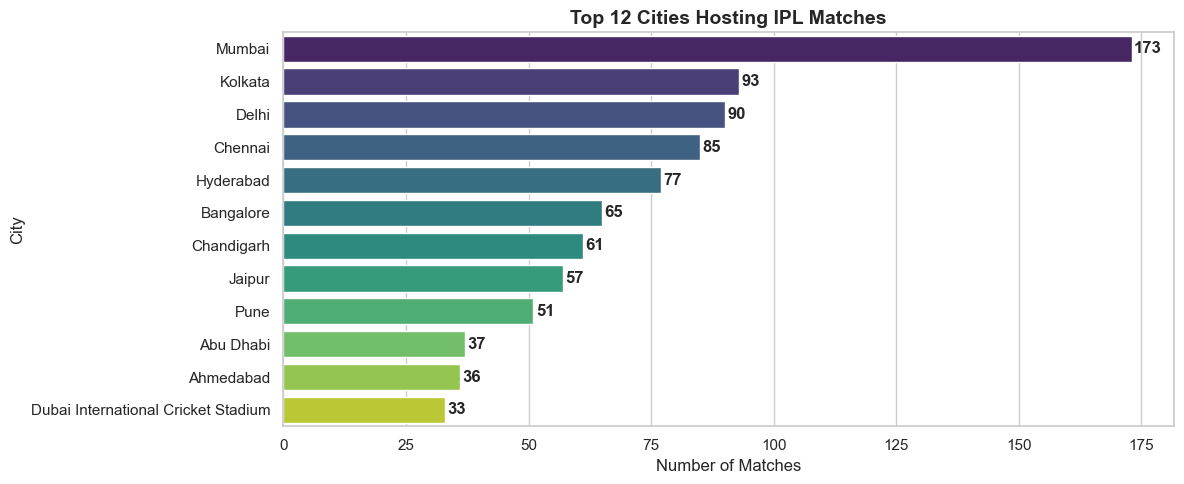

Insight: Mumbai and Kolkata consistently host the most IPL matches every season.


In [10]:
city_counts = df['city'].value_counts().head(12)

plt.figure(figsize=(12, 5))
sns.barplot(x=city_counts.values, y=city_counts.index, palette='viridis')
plt.title('Top 12 Cities Hosting IPL Matches', fontsize=14, fontweight='bold')
plt.xlabel('Number of Matches')
plt.ylabel('City')
for i, v in enumerate(city_counts.values):
    plt.text(v + 0.5, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../output/eda_top_cities.png', dpi=150)
plt.show()
print('Insight: Mumbai and Kolkata consistently host the most IPL matches every season.')

### Chart 7 — Season-wise Win Type (Bat First vs Chase)

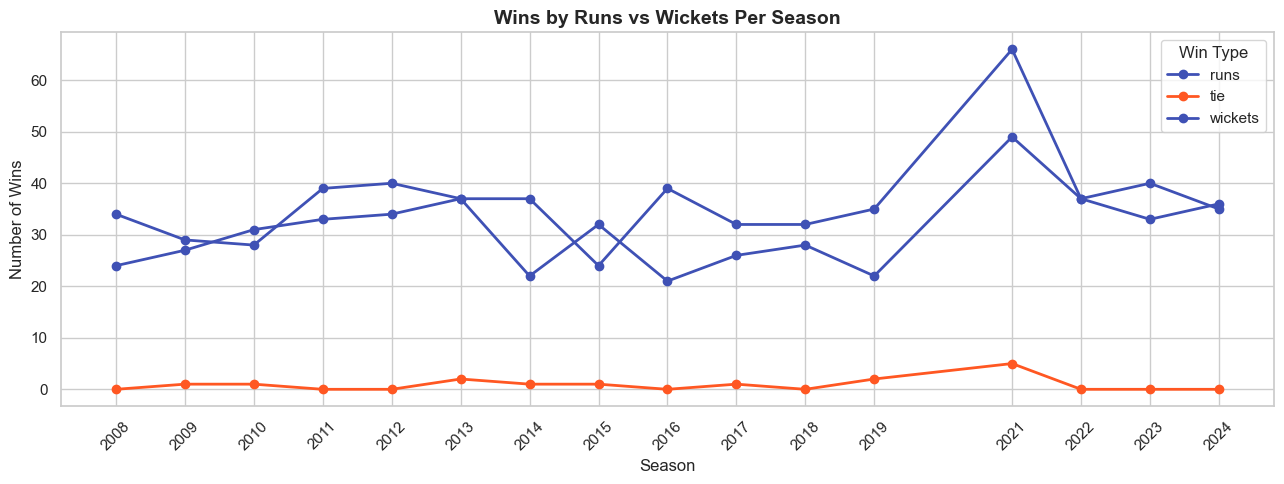

Insight: Wins by wickets (chasing) dominate across all seasons — T20 favors chasing teams.


In [11]:
win_type_season = df[df['winner'] != 'No Result'].groupby(['season', 'result']).size().unstack(fill_value=0)

win_type_season.plot(kind='line', figsize=(13, 5), marker='o',
                     color=['#3F51B5', '#FF5722'], linewidth=2)
plt.title('Wins by Runs vs Wickets Per Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Wins')
plt.xticks(win_type_season.index, rotation=45)
plt.legend(title='Win Type')
plt.tight_layout()
plt.savefig('../output/eda_win_type_season.png', dpi=150)
plt.show()
print('Insight: Wins by wickets (chasing) dominate across all seasons — T20 favors chasing teams.')

## 5. Key Findings Report

In [12]:
print('=' * 55)
print('EDA REPORT — IPL MATCHES DATASET')
print('=' * 55)
print(f'Total Matches Analyzed : {len(df)}')
print(f'Seasons Covered        : {df["season"].min()} to {df["season"].max()}')
print(f'Unique Teams           : {df["team1"].nunique()}')
print(f'Unique Venues          : {df["venue"].nunique()}')
print(f'Unique Cities          : {df["city"].nunique()}')
print()
print('KEY FINDINGS:')
print('-' * 55)
top_team = df[df['winner'] != 'No Result']['winner'].value_counts().index[0]
print(f'1. Most successful team     : {top_team}')
field_pct = round(df[df['toss_decision']=='field'].shape[0] / len(df) * 100, 1)
print(f'2. Teams choosing to field  : {field_pct}% (prefer chasing)')
toss_win_pct = round((df['toss_winner'] == df['winner']).mean() * 100, 1)
print(f'3. Toss winner wins match   : {toss_win_pct}% (near 50-50, toss barely matters)')
top_city = df['city'].value_counts().index[0]
print(f'4. Most matches hosted city : {top_city}')
chase_pct = round(df[df['result']=='wickets'].shape[0] / df[df['winner']!='No Result'].shape[0] * 100, 1)
print(f'5. Matches won by chasing   : {chase_pct}%')
print()
print('CONCLUSION:')
print('Chasing is the dominant strategy in IPL. Toss outcome')
print('has minimal effect on match results. Team quality and')
print('player performance are the real deciding factors.')

EDA REPORT — IPL MATCHES DATASET
Total Matches Analyzed : 1095
Seasons Covered        : 2008 to 2024
Unique Teams           : 19
Unique Venues          : 58
Unique Cities          : 38

KEY FINDINGS:
-------------------------------------------------------
1. Most successful team     : Mumbai Indians
2. Teams choosing to field  : 64.3% (prefer chasing)
3. Toss winner wins match   : 50.6% (near 50-50, toss barely matters)
4. Most matches hosted city : Mumbai
5. Matches won by chasing   : 53.0%

CONCLUSION:
Chasing is the dominant strategy in IPL. Toss outcome
has minimal effect on match results. Team quality and
player performance are the real deciding factors.


## What Each EDA Term Means

| Term | Simple Meaning |
|---|---|
| **EDA** | Exploring data to find patterns before building models |
| **Statistical Summary** | Mean, median, min, max of numerical columns |
| **Correlation** | How strongly two columns are related to each other |
| **Heatmap** | Color-coded table showing correlation between all columns |
| **Distribution** | How values are spread — mostly low, high, or equal? |
| **Trend** | How something changes over time (seasons in this case) |
| **Win Rate** | Wins divided by total matches played × 100 |